In [13]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [14]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 13
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

In [16]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [17]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [18]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss() # какой лосс удобный возьмем для бинарной сегментации?
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()


    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)


    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")


    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)


    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)


    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)


    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [19]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [20]:
trainer.run()

100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


Epoch 1 / 13, Train Loss: 0.4630, Val Loss: 0.3794, Val IoU: 0.8025, Val F1-score: 0.8847


100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 2 / 13, Train Loss: 0.3394, Val Loss: 0.3165, Val IoU: 0.8396, Val F1-score: 0.9079


100%|██████████| 23/23 [00:11<00:00,  1.94it/s]


...

Epoch 12 / 13, Train Loss: 0.1339, Val Loss: 0.2355, Val IoU: 0.8743, Val F1-score: 0.9292


100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


Epoch 13 / 13, Train Loss: 0.1347, Val Loss: 0.2076, Val IoU: 0.8852, Val F1-score: 0.9360
Testing...


100%|██████████| 115/115 [01:01<00:00,  1.86it/s]

Test Loss: 0.2103, Test IoU: 0.8815, Test F1-score: 0.9324


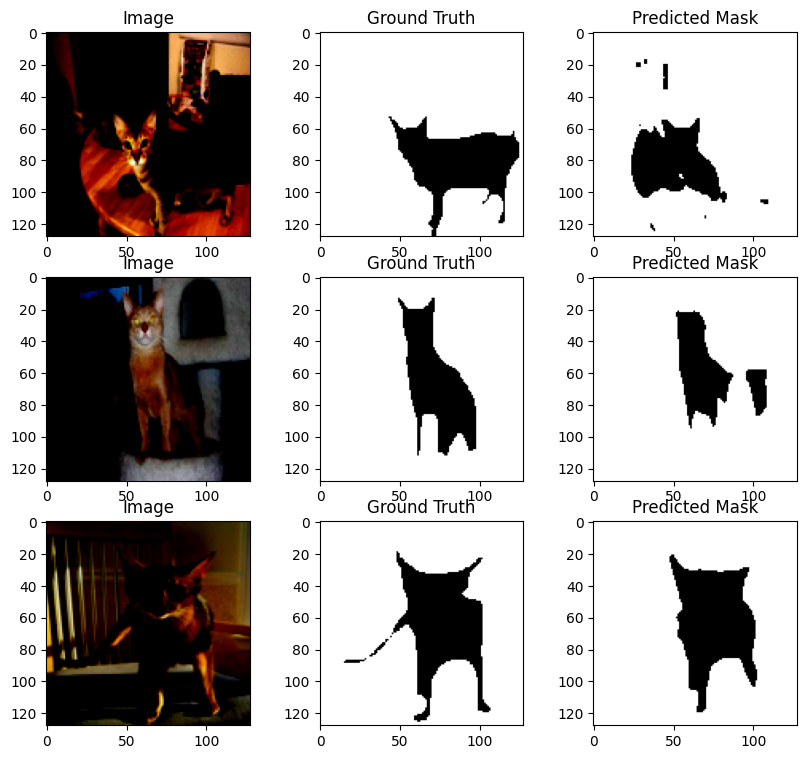

In [21]:
trainer.inference_and_plot_samples(n_samples=3)

In [22]:
def run_experiments():
    lrs = [1e-3, 1e-4, 5e-4]
    batch_sizes = [8, 16, 32]

    all_logs = {}

    for lr in lrs:
        for bs in batch_sizes:
            print(f"Running lr={lr}, bs={bs}")

            cfg = Config()
            cfg.learning_rate = lr
            cfg.batch_size = bs

            trainer = Trainer(cfg)

            train_losses, val_losses = [], []

            for epoch in range(cfg.epochs):
                train_loss = trainer.train()
                val_loss, _, _ = trainer.validate()

                train_losses.append(train_loss)
                val_losses.append(val_loss)

            all_logs[(lr, bs)] = {
                "train": train_losses,
                "val": val_losses
            }

    print("\nResults:")
    for k, v in all_logs.items():
        print(k, v)

    return all_logs

In [23]:
def plot_experiments(all_logs):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 10))

    for (lr, bs), logs in all_logs.items():
        label = f"lr={lr}, bs={bs}"
        plt.plot(logs["val"], label=label)

    plt.title("Validation Loss for different hyperparameters")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

Running lr=0.001, bs=8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:14<00:00,  6.52it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Running lr=0.001, bs=16


100%|██████████| 46/46 [00:13<00:00,  3.51it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Running lr=0.001, bs=32


...

Running lr=0.0005, bs=16


100%|██████████| 46/46 [00:13<00:00,  3.44it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Running lr=0.0005, bs=32


100%|██████████| 23/23 [00:12<00:00,  1.82it/s]



Results:
(0.001, 8) {'train': [0.4597990487742683, 0.41254519096211245, 0.3718304201636625, 0.3223156282354308, 0.28756297480962845, 0.26500992193494155, 0.2440912216172918, 0.23357977847690167, 0.2218250290936102, 0.21392272315595462, 0.19977221690604222, 0.19139074795353023, 0.180474987719208], 'val': [0.4170131171527116, 0.41007126025531604, 0.36291830500830774, 0.2982718699976154, 0.2770776920344519, 0.2866601475878902, 0.25783460101355676, 0.2523930764392666, 0.2268238551914692, 0.22613017989889436, 0.233029427897671, 0.20463230177436187, 0.21041858309636946]}
(0.001, 16) {'train': [0.4832324952535007, 0.37991645608259283, 0.32870154520091804, 0.29349506597803987, 0.2748081259753393, 0.2555405038368443, 0.23979490355628988, 0.22160120559451374, 0.2116380730724853, 0.2027962907500889, 0.18961876080087994, 0.18129398953169584, 0.17470479606772246], 'val': [0.4065044314964958, 0.33941336883151013, 0.5051648383555205, 0.336236885384373, 0.3107168949816538, 0.23512082514555557, 0.2174

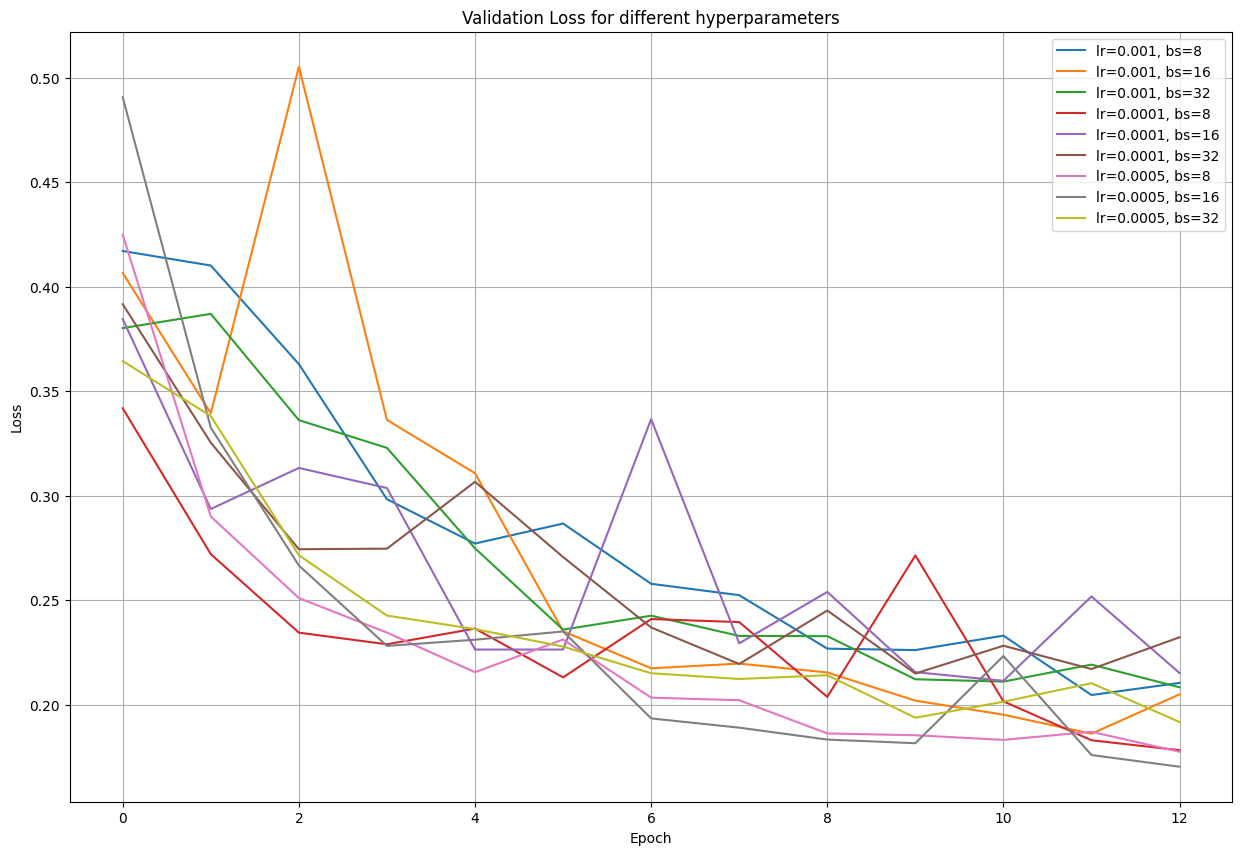

In [24]:
logs = run_experiments()
plot_experiments(logs)

**Вывод**

**learning rate**

По графику видно, что при lr = 0.001 есть резкие скачки loss,
особенно при меньших batch size. Это указывает на слишком большой шаг обучения.


При lr = 0.0001 обучение более плавное, но сходимость медленная.

Наиболее удачным оказался lr = 0.0005, где loss убывает достаточно быстро и без сильных колебаний.


**batch size**

малые batch size дают более шумные кривые
большие batch size более стабильны, но иногда сходятся хуже

**Итог**

Лучший баланс между скоростью сходимости и стабильностью достигается при lr = 0.0005 и batch size 16–32.

In [29]:
class DoubleConvDropout(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [30]:
class UNetModified(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConvDropout(in_channels, 32)
        self.enc2 = DoubleConvDropout(32, 64)
        self.enc3 = DoubleConvDropout(64, 128)
        self.enc4 = DoubleConvDropout(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConvDropout(256, 512)

        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = DoubleConvDropout(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConvDropout(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConvDropout(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConvDropout(64, 32)

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [31]:
def run_modified_experiment():
    cfg = Config()
    trainer = Trainer(cfg)
    trainer.model = UNetModified().to(cfg.device)

    train_losses = []
    val_losses = []
    val_ious = []
    val_f1s = []

    for epoch in range(cfg.epochs):
        train_loss = trainer.train()
        val_loss, val_iou, val_f1 = trainer.validate()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_ious.append(val_iou)
        val_f1s.append(val_f1)

        print(f"Epoch {epoch+1}/{cfg.epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, IoU: {val_iou:.4f}, F1: {val_f1:.4f}")

    test_loss, test_iou, test_f1 = trainer.test()

    print(f"Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}, Test F1: {test_f1:.4f}")

    return train_losses, val_losses

In [32]:
def plot_modified(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.title("Modified U-Net Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

In [33]:
train_losses, val_losses = run_modified_experiment()

100%|██████████| 23/23 [00:10<00:00,  2.14it/s]


Epoch 1/13, Train Loss: 0.6577, Val Loss: 0.6495, IoU: 0.6606, F1: 0.7838


100%|██████████| 23/23 [00:10<00:00,  2.12it/s]


Epoch 2/13, Train Loss: 0.6562, Val Loss: 0.6489, IoU: 0.6609, F1: 0.7840


100%|██████████| 23/23 [00:10<00:00,  2.26it/s]


...

Epoch 12/13, Train Loss: 0.6568, Val Loss: 0.6493, IoU: 0.6586, F1: 0.7822


100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 13/13, Train Loss: 0.6565, Val Loss: 0.6497, IoU: 0.6587, F1: 0.7823


100%|██████████| 115/115 [00:57<00:00,  2.01it/s]

Test Loss: 0.6511, Test IoU: 0.6547, Test F1: 0.7787


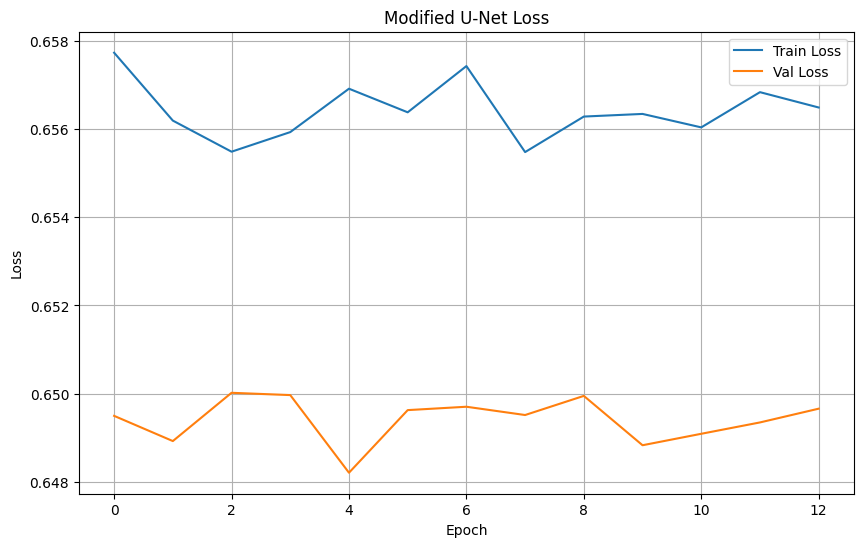

In [34]:
plot_modified(train_losses, val_losses)

**Вывод**
Модифицированный U-Net показал значительно худшие результаты по сравнению с базовой моделью:

IoU снизился с ~0.88 до ~0.65
F1-score снизился с ~0.93 до ~0.78
Loss остался на высоком уровне и почти не уменьшался